# Download GEFSv12 Control Member Pressure Level Variables (u, v, Z, SBCAPE)

Importing Packages

In [2]:
!pip install cartopy

import pandas as pd
import requests
import os
from pathlib import Path
import xarray as xr
import warnings
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 90.4 MB/s eta 0:00:00


### Downloading the Raw .grib2 Files

In [ ]:
# This code was generously provided by prior students, Daniel Wefer and Paul Eldridge, and adapted for this project.
if __name__ == "__main__":
    out_dir = Path("/home/scratch/lmoeller/GEFSv12_ref_483/Hail_Input")
    os.makedirs(out_dir, exist_ok=True)

    years = range(2015, 2020)
    variables = ["hgt_pres", "ugrd_pres", "vgrd_pres", "cape_sfc"]

    for year in years:

        dates = pd.date_range(start=f"{year}-05-01", end=f"{year}-05-31", freq="1D")

        for dtime in dates:
            ymd = dtime.strftime("%Y%m%d")
            month = dtime.month

            folder = out_dir / str(year) / f"{month:02d}"
            folder.mkdir(parents=True, exist_ok=True)

            for var in variables:
                if var == "cape_sfc":
                    url = f"https://noaa-gefs-retrospective.s3.amazonaws.com/GEFSv12/reforecast/{year}/{ymd}00/c00/Days%3A1-10/cape_sfc_{ymd}00_c00.grib2"
                    local_path = folder / f"cape_sfc_{ymd}00_c00.grib2"
                else:
                    below_url = f"https://noaa-gefs-retrospective.s3.amazonaws.com/GEFSv12/reforecast/{year}/{ymd}00/c00/Days%3A1-10/{var}_{ymd}00_c00.grib2"
                    below = folder / f"{var}_{ymd}00_c00.grib2"

                    with requests.get(below_url, stream=True) as r:
                        r.raise_for_status()
                        with open(below, "wb") as f:
                            for chunk in r.iter_content(chunk_size=1024 * 1024):
                                if chunk:
                                    f.write(chunk)

                    above_url = f"https://noaa-gefs-retrospective.s3.amazonaws.com/GEFSv12/reforecast/{year}/{ymd}00/c00/Days%3A1-10/{var}_abv700mb_{ymd}00_c00.grib2"
                    above = folder / f"{var}_abv700mb_{ymd}00_c00.grib2"

                    with requests.get(above_url, stream=True) as r:
                        r.raise_for_status()
                        with open(above, "wb") as f:
                            for chunk in r.iter_content(chunk_size=1024 * 1024):
                                if chunk:
                                    f.write(chunk)
                    continue

                with requests.get(url, stream=True) as r:
                    r.raise_for_status()
                    with open(local_path, "wb") as f:
                        for chunk in r.iter_content(chunk_size=1024 * 1024):
                            if chunk:
                                f.write(chunk)

            print(f"Completed {dtime.date()}")

Completed 2015-05-01
Completed 2015-05-02
Completed 2015-05-03
Completed 2015-05-04
Completed 2015-05-05
Completed 2015-05-06
Completed 2015-05-07
Completed 2015-05-08
Completed 2015-05-09
Completed 2015-05-10
Completed 2015-05-11
Completed 2015-05-12
Completed 2015-05-13
Completed 2015-05-14
Completed 2015-05-15
Completed 2015-05-16
Completed 2015-05-17
Completed 2015-05-18
Completed 2015-05-19
Completed 2015-05-20
Completed 2015-05-21
Completed 2015-05-22
Completed 2015-05-23
Completed 2015-05-24
Completed 2015-05-25
Completed 2015-05-26
Completed 2015-05-27
Completed 2015-05-28
Completed 2015-05-29
Completed 2015-05-30
Completed 2015-05-31
Completed 2016-05-01
Completed 2016-05-02
Completed 2016-05-03
Completed 2016-05-04
Completed 2016-05-05
Completed 2016-05-06
Completed 2016-05-07
Completed 2016-05-08
Completed 2016-05-09
Completed 2016-05-10
Completed 2016-05-11
Completed 2016-05-12
Completed 2016-05-13
Completed 2016-05-14
Completed 2016-05-15
Completed 2016-05-16
Completed 201

### Creating the Pressure Levels .nc Files

In [ ]:
warnings.filterwarnings("ignore")

input_base = Path("/home/scratch/lmoeller/GEFSv12_ref_483/Hail_Input")
output_base = Path("/home/scratch/lmoeller/GEFSv12_ref_483/pres_lvl_nc")

variables = ["hgt_pres", "ugrd_pres", "vgrd_pres"]

lat_slice = slice(23, 51)
lon_slice = slice(-107, -65)

desired_steps = [pd.Timedelta(hours=h) for h in range(3, 121, 3)]


def process_date(dtime):
    yr = dtime.year
    mo = dtime.month
    date_str = f"{yr}{mo:02d}{dtime.day:02d}00"

    out_folder = output_base / str(yr) / f"{mo:02d}"
    out_folder.mkdir(parents=True, exist_ok=True)
    out_file = out_folder / f"gefs_c00_{date_str}_pres_subset.nc"

    datasets = []

    for var in variables:
        file_low = input_base / str(yr) / f"{mo:02d}" / f"{var}_{date_str}_c00.grib2"
        file_abv = input_base / str(yr) / f"{mo:02d}" / f"{var}_abv700mb_{date_str}_c00.grib2"

        paths = [p for p in [file_low, file_abv] if p.exists()]

        if not paths:
            print(f"Missing files for {var} on {dtime.date()}")
            continue

        if len(paths) == 1:
            ds_var = xr.open_dataset(paths[0], engine="cfgrib", backend_kwargs={"indexpath": ""})
        else:
            ds_var = xr.open_mfdataset(
                paths,
                engine="cfgrib",
                backend_kwargs={"indexpath": ""},
                combine="nested",
                concat_dim="isobaricInhPa",
                coords="minimal",
                compat="override",
                data_vars="minimal"
            )

        ds_var = ds_var.assign_coords(
            longitude=((ds_var.longitude + 180) % 360) - 180
        ).sortby("longitude")

        ds_var = ds_var.sel(latitude=lat_slice, longitude=lon_slice, step=desired_steps)
        datasets.append(ds_var)

    if not datasets:
        print(f"No data for {dtime.date()}")
        return

    ds_merged = xr.merge(datasets, compat="override")

    encoding = {v: {"zlib": True, "complevel": 4} for v in ds_merged.data_vars}
    ds_merged.to_netcdf(out_file, encoding=encoding)

    print(f"Saved {out_file.name}  ({out_file.stat().st_size / (1024**2):.1f} MB)")


def main():
    for year in range(2015, 2020):

        dates = pd.date_range(start=f"{year}-05-01", end=f"{year}-05-31", freq="1D")

        for d in dates:
            process_date(d)


if __name__ == "__main__":
    main()

Saved gefs_c00_2015050100_pres_subset.nc  (75.8 MB)
Saved gefs_c00_2015050200_pres_subset.nc  (75.9 MB)
Saved gefs_c00_2015050300_pres_subset.nc  (76.6 MB)
Saved gefs_c00_2015050400_pres_subset.nc  (75.5 MB)
Saved gefs_c00_2015050500_pres_subset.nc  (75.9 MB)
Saved gefs_c00_2015050600_pres_subset.nc  (77.0 MB)
Saved gefs_c00_2015050700_pres_subset.nc  (76.7 MB)
Saved gefs_c00_2015050800_pres_subset.nc  (77.0 MB)
Saved gefs_c00_2015050900_pres_subset.nc  (76.8 MB)
Saved gefs_c00_2015051000_pres_subset.nc  (76.2 MB)
Saved gefs_c00_2015051100_pres_subset.nc  (75.9 MB)
Saved gefs_c00_2015051200_pres_subset.nc  (75.0 MB)
Saved gefs_c00_2015051300_pres_subset.nc  (74.5 MB)
Saved gefs_c00_2015051400_pres_subset.nc  (73.1 MB)
Saved gefs_c00_2015051500_pres_subset.nc  (73.3 MB)
Saved gefs_c00_2015051600_pres_subset.nc  (74.8 MB)
Saved gefs_c00_2015051700_pres_subset.nc  (77.9 MB)
Saved gefs_c00_2015051800_pres_subset.nc  (75.2 MB)
Saved gefs_c00_2015051900_pres_subset.nc  (77.1 MB)
Saved gefs_c

### Creating the SBCAPE .nc Files

In [ ]:
warnings.filterwarnings("ignore")

input_base = Path("/home/scratch/lmoeller/GEFSv12_ref_483/Hail_Input")
output_base = Path("/home/scratch/lmoeller/GEFSv12_ref_483/sbcape_nc")


def process_date(dtime):
    yr = dtime.year
    mo = dtime.month
    date_str = f"{yr}{mo:02d}{dtime.day:02d}00"

    out_folder = output_base / str(yr) / f"{mo:02d}"
    out_folder.mkdir(parents=True, exist_ok=True)
    out_file = out_folder / f"gefs_c00_{date_str}_sbcape_subset.nc"

    cape_file = input_base / str(yr) / f"{mo:02d}" / f"cape_sfc_{date_str}_c00.grib2"

    ds = xr.open_dataset(cape_file, engine="cfgrib", backend_kwargs={"indexpath": ""})

    ds = ds.assign_coords(longitude=((ds.longitude + 180) % 360) - 180).sortby("longitude")

    ds = ds.where((ds.latitude >= 23) & (ds.latitude <= 51), drop=True)
    ds = ds.sel(longitude=slice(-107, -65))
    ds = ds.isel(step=slice(1, 41))

    encoding = {"cape": {"zlib": True, "complevel": 5}}
    ds.to_netcdf(out_file, encoding=encoding)

    print(f"Saved {out_file.name}  ({out_file.stat().st_size / (1024**2):.1f} MB)")


def main():
    for year in range(2011, 2020):
        dates = pd.date_range(start=f"{year}-05-01", end=f"{year}-05-31", freq="1D")

        for d in dates:
            process_date(d)

if __name__ == "__main__":
    main()

Saved gefs_c00_2011050100_sbcape_subset.nc  (0.5 MB)
Saved gefs_c00_2011050200_sbcape_subset.nc  (0.5 MB)
Saved gefs_c00_2011050300_sbcape_subset.nc  (0.5 MB)
Saved gefs_c00_2011050400_sbcape_subset.nc  (0.5 MB)
Saved gefs_c00_2011050500_sbcape_subset.nc  (0.6 MB)
Saved gefs_c00_2011050600_sbcape_subset.nc  (0.6 MB)
Saved gefs_c00_2011050700_sbcape_subset.nc  (0.7 MB)
Saved gefs_c00_2011050800_sbcape_subset.nc  (0.7 MB)
Saved gefs_c00_2011050900_sbcape_subset.nc  (0.7 MB)
Saved gefs_c00_2011051000_sbcape_subset.nc  (0.7 MB)
Saved gefs_c00_2011051100_sbcape_subset.nc  (0.6 MB)
Saved gefs_c00_2011051200_sbcape_subset.nc  (0.6 MB)
Saved gefs_c00_2011051300_sbcape_subset.nc  (0.5 MB)
Saved gefs_c00_2011051400_sbcape_subset.nc  (0.5 MB)
Saved gefs_c00_2011051500_sbcape_subset.nc  (0.5 MB)
Saved gefs_c00_2011051600_sbcape_subset.nc  (0.6 MB)
Saved gefs_c00_2011051700_sbcape_subset.nc  (0.7 MB)
Saved gefs_c00_2011051800_sbcape_subset.nc  (0.7 MB)
Saved gefs_c00_2011051900_sbcape_subset.nc  (0

### Displaying the GEFSv12 Reforecast .nc Files to Ensure Accuracy

Let's look at some sample .nc files that were calculated. Download from the OneDrive folder and then upload into the Google Colab local directory:

https://niuits-my.sharepoint.com/:f:/g/personal/z1953922_students_niu_edu/IgB7Zg9PyxWmTZGvWGEDh-wDAXEes_lRU5IM91oNSfTa_Qw?e=mkSzmN

/tmp/ipykernel_28354/1897454195.py:6: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(nc_file)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultura

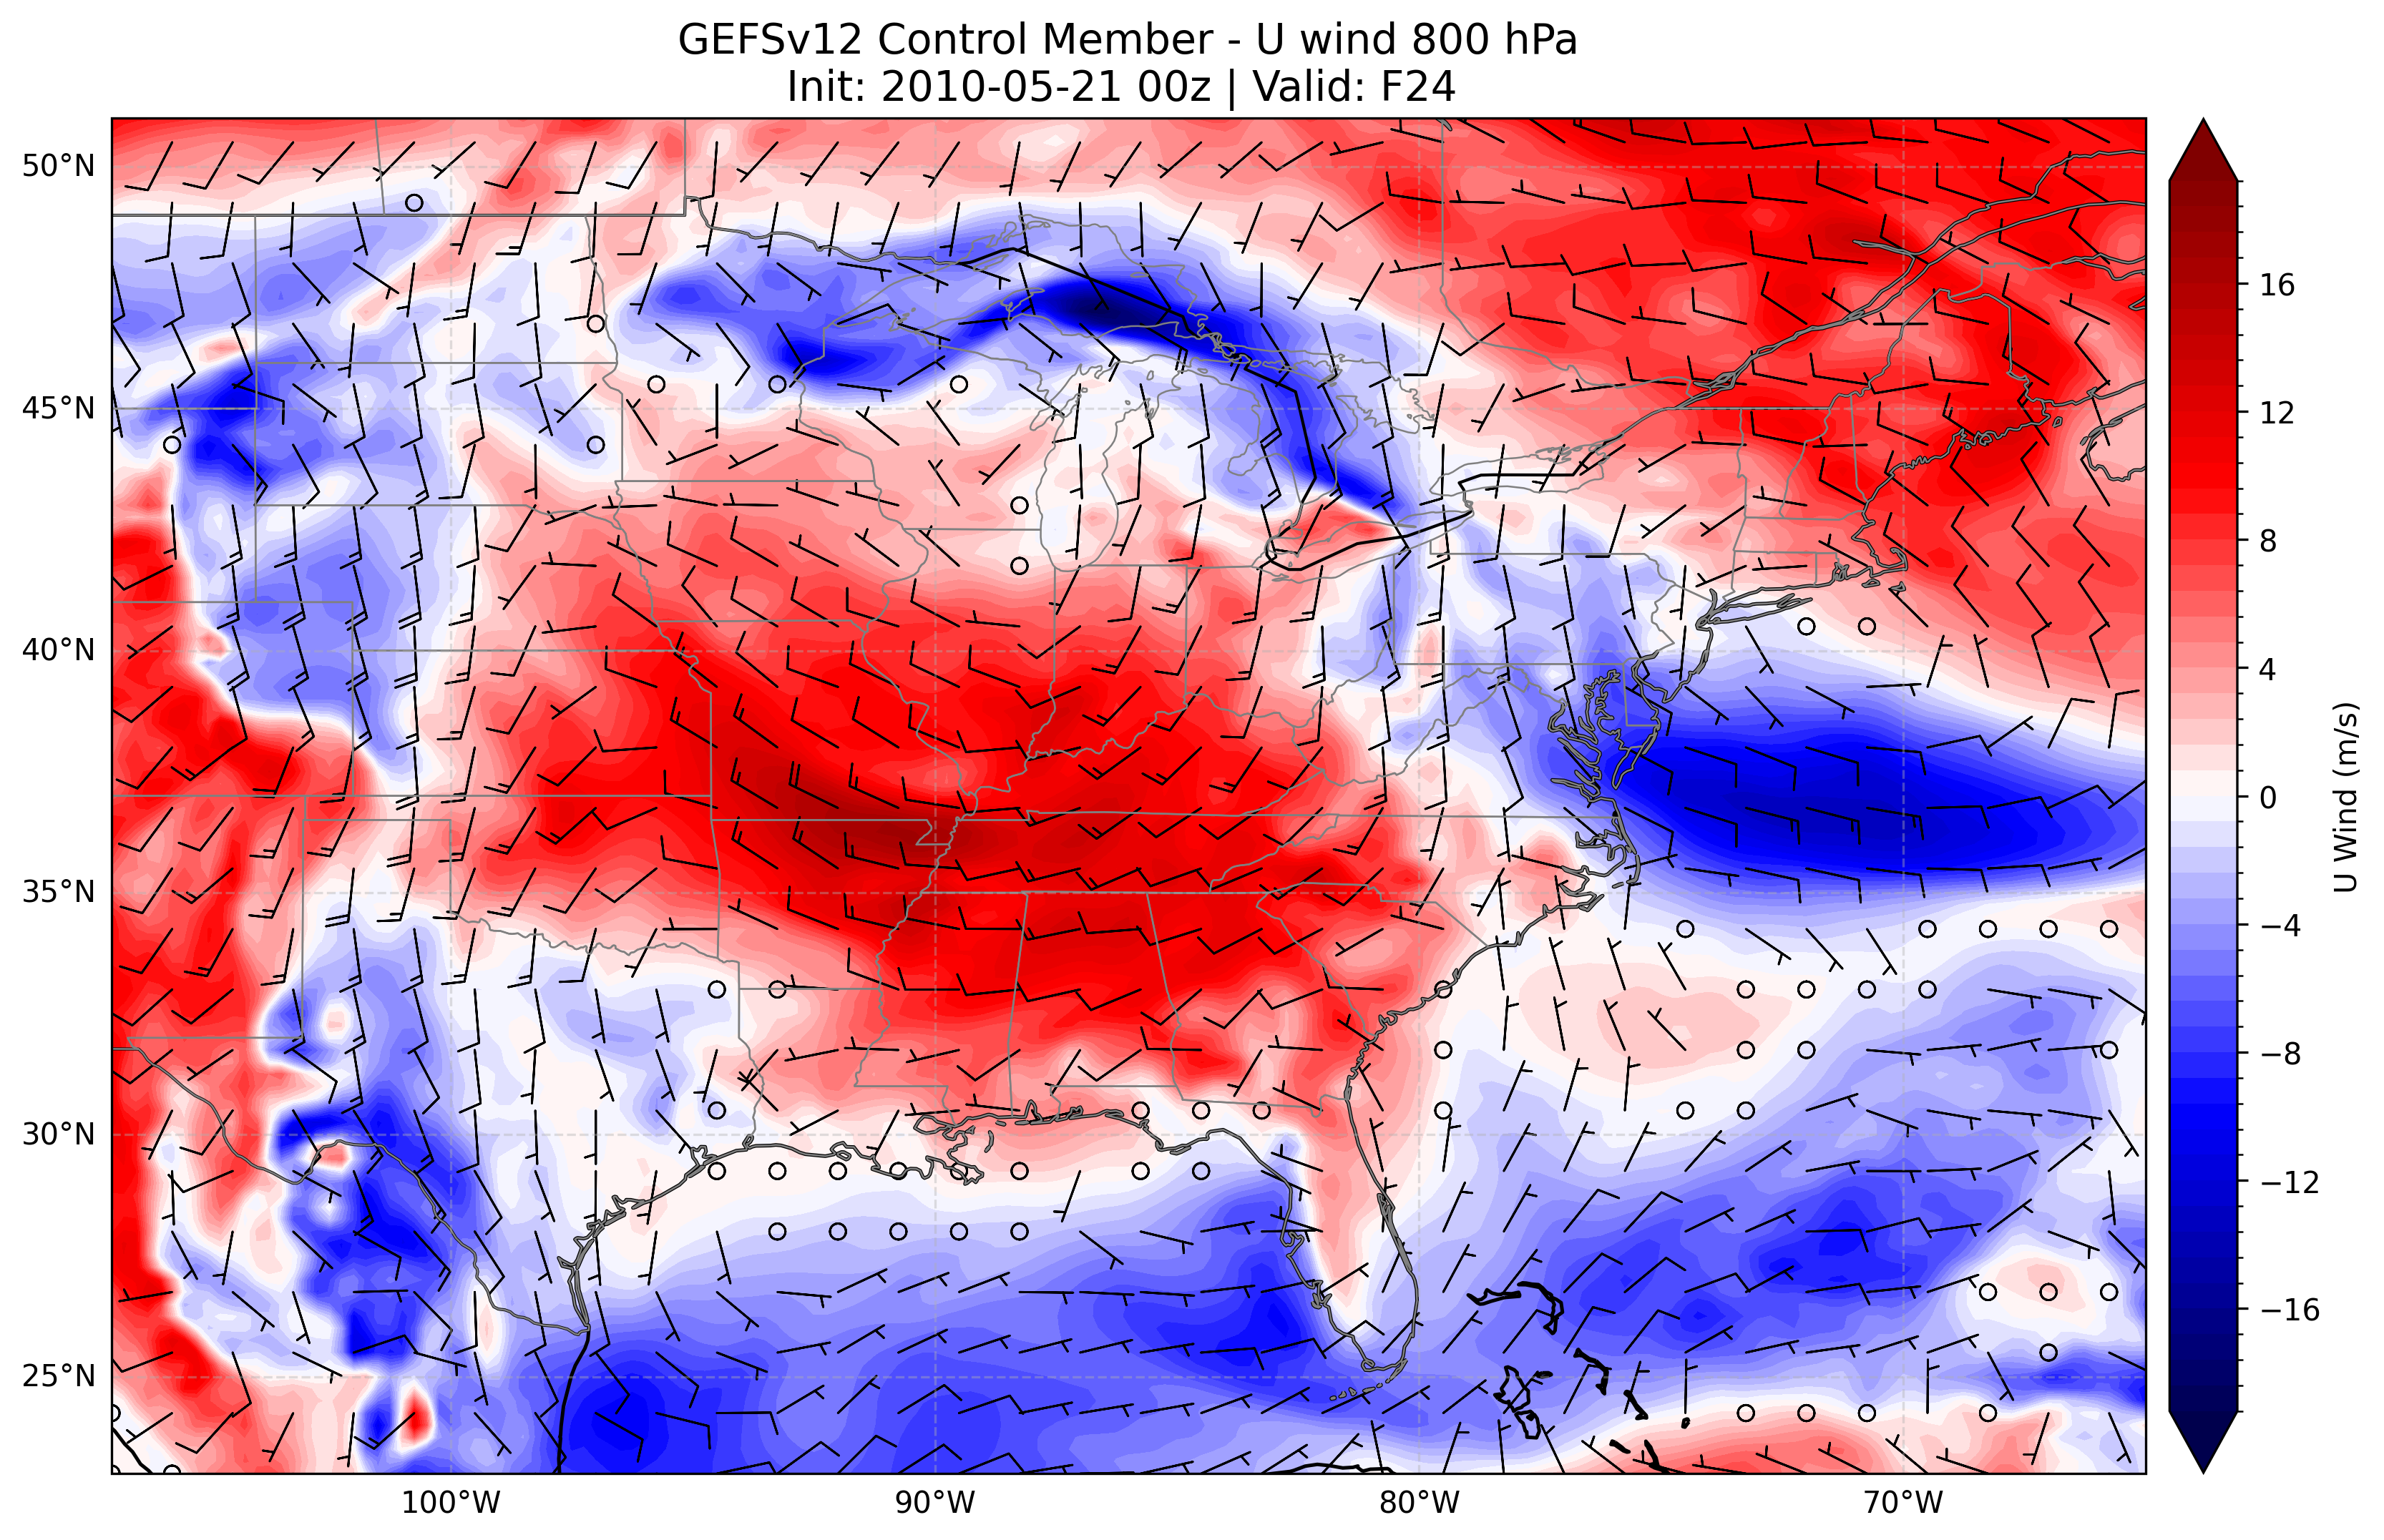

In [3]:
nc_file = "gefs_c00_2010052100_pres_subset.nc"

pressure_level = 800
step_hours = 24

ds = xr.open_dataset(nc_file)

u = ds['u'].sel(isobaricInhPa=pressure_level, step=pd.Timedelta(hours=step_hours))

v = ds['v'].sel(isobaricInhPa=pressure_level, step=pd.Timedelta(hours=step_hours))

fig = plt.figure(figsize=(12, 9), dpi=300)
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())

contour = u.plot.contourf(ax=ax, cmap='seismic', levels=50, extend='both', transform=ccrs.PlateCarree(),
                          cbar_kwargs={'label': 'U Wind (m/s)', 'shrink': 0.725, 'pad': 0.01})
skip = 5
ax.barbs(u.longitude[::skip], u.latitude[::skip], u.values[::skip, ::skip], v.values[::skip, ::skip],
         length=6, linewidth=0.7, transform=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=1.2)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=1.0)
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.6, edgecolor='gray')

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
gl.top_labels = False
gl.right_labels = False

plt.title(f"GEFSv12 Control Member - U wind {pressure_level} hPa\nInit: 2010-05-21 00z | Valid: F{step_hours} ", fontsize=14)

plt.tight_layout()
plt.show()

In [4]:
ds

<xarray.Dataset> Size: 229MB
Dimensions:        (step: 40, isobaricInhPa: 25, latitude: 113, longitude: 169)
Coordinates:
  * step           (step) timedelta64[ns] 320B 0 days 03:00:00 ... 5 days 00:...
  * isobaricInhPa  (isobaricInhPa) float64 200B 1e+03 975.0 950.0 ... 2.0 1.0
  * latitude       (latitude) float64 904B 23.0 23.25 23.5 ... 50.5 50.75 51.0
  * longitude      (longitude) float64 1kB -107.0 -106.8 -106.5 ... -65.25 -65.0
    number         int64 8B 0
    time           datetime64[ns] 8B 2010-05-21
    valid_time     (step) datetime64[ns] 320B ...
Data variables:
    gh             (step, isobaricInhPa, latitude, longitude) float32 76MB ...
    u              (step, isobaricInhPa, latitude, longitude) float32 76MB ...
    v              (step, isobaricInhPa, latitude, longitude) float32 76MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-12T06:21 GRIB to CDM+CF via cfgrib-0.9.1...

/tmp/ipykernel_28354/2228243035.py:5: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(nc_file)


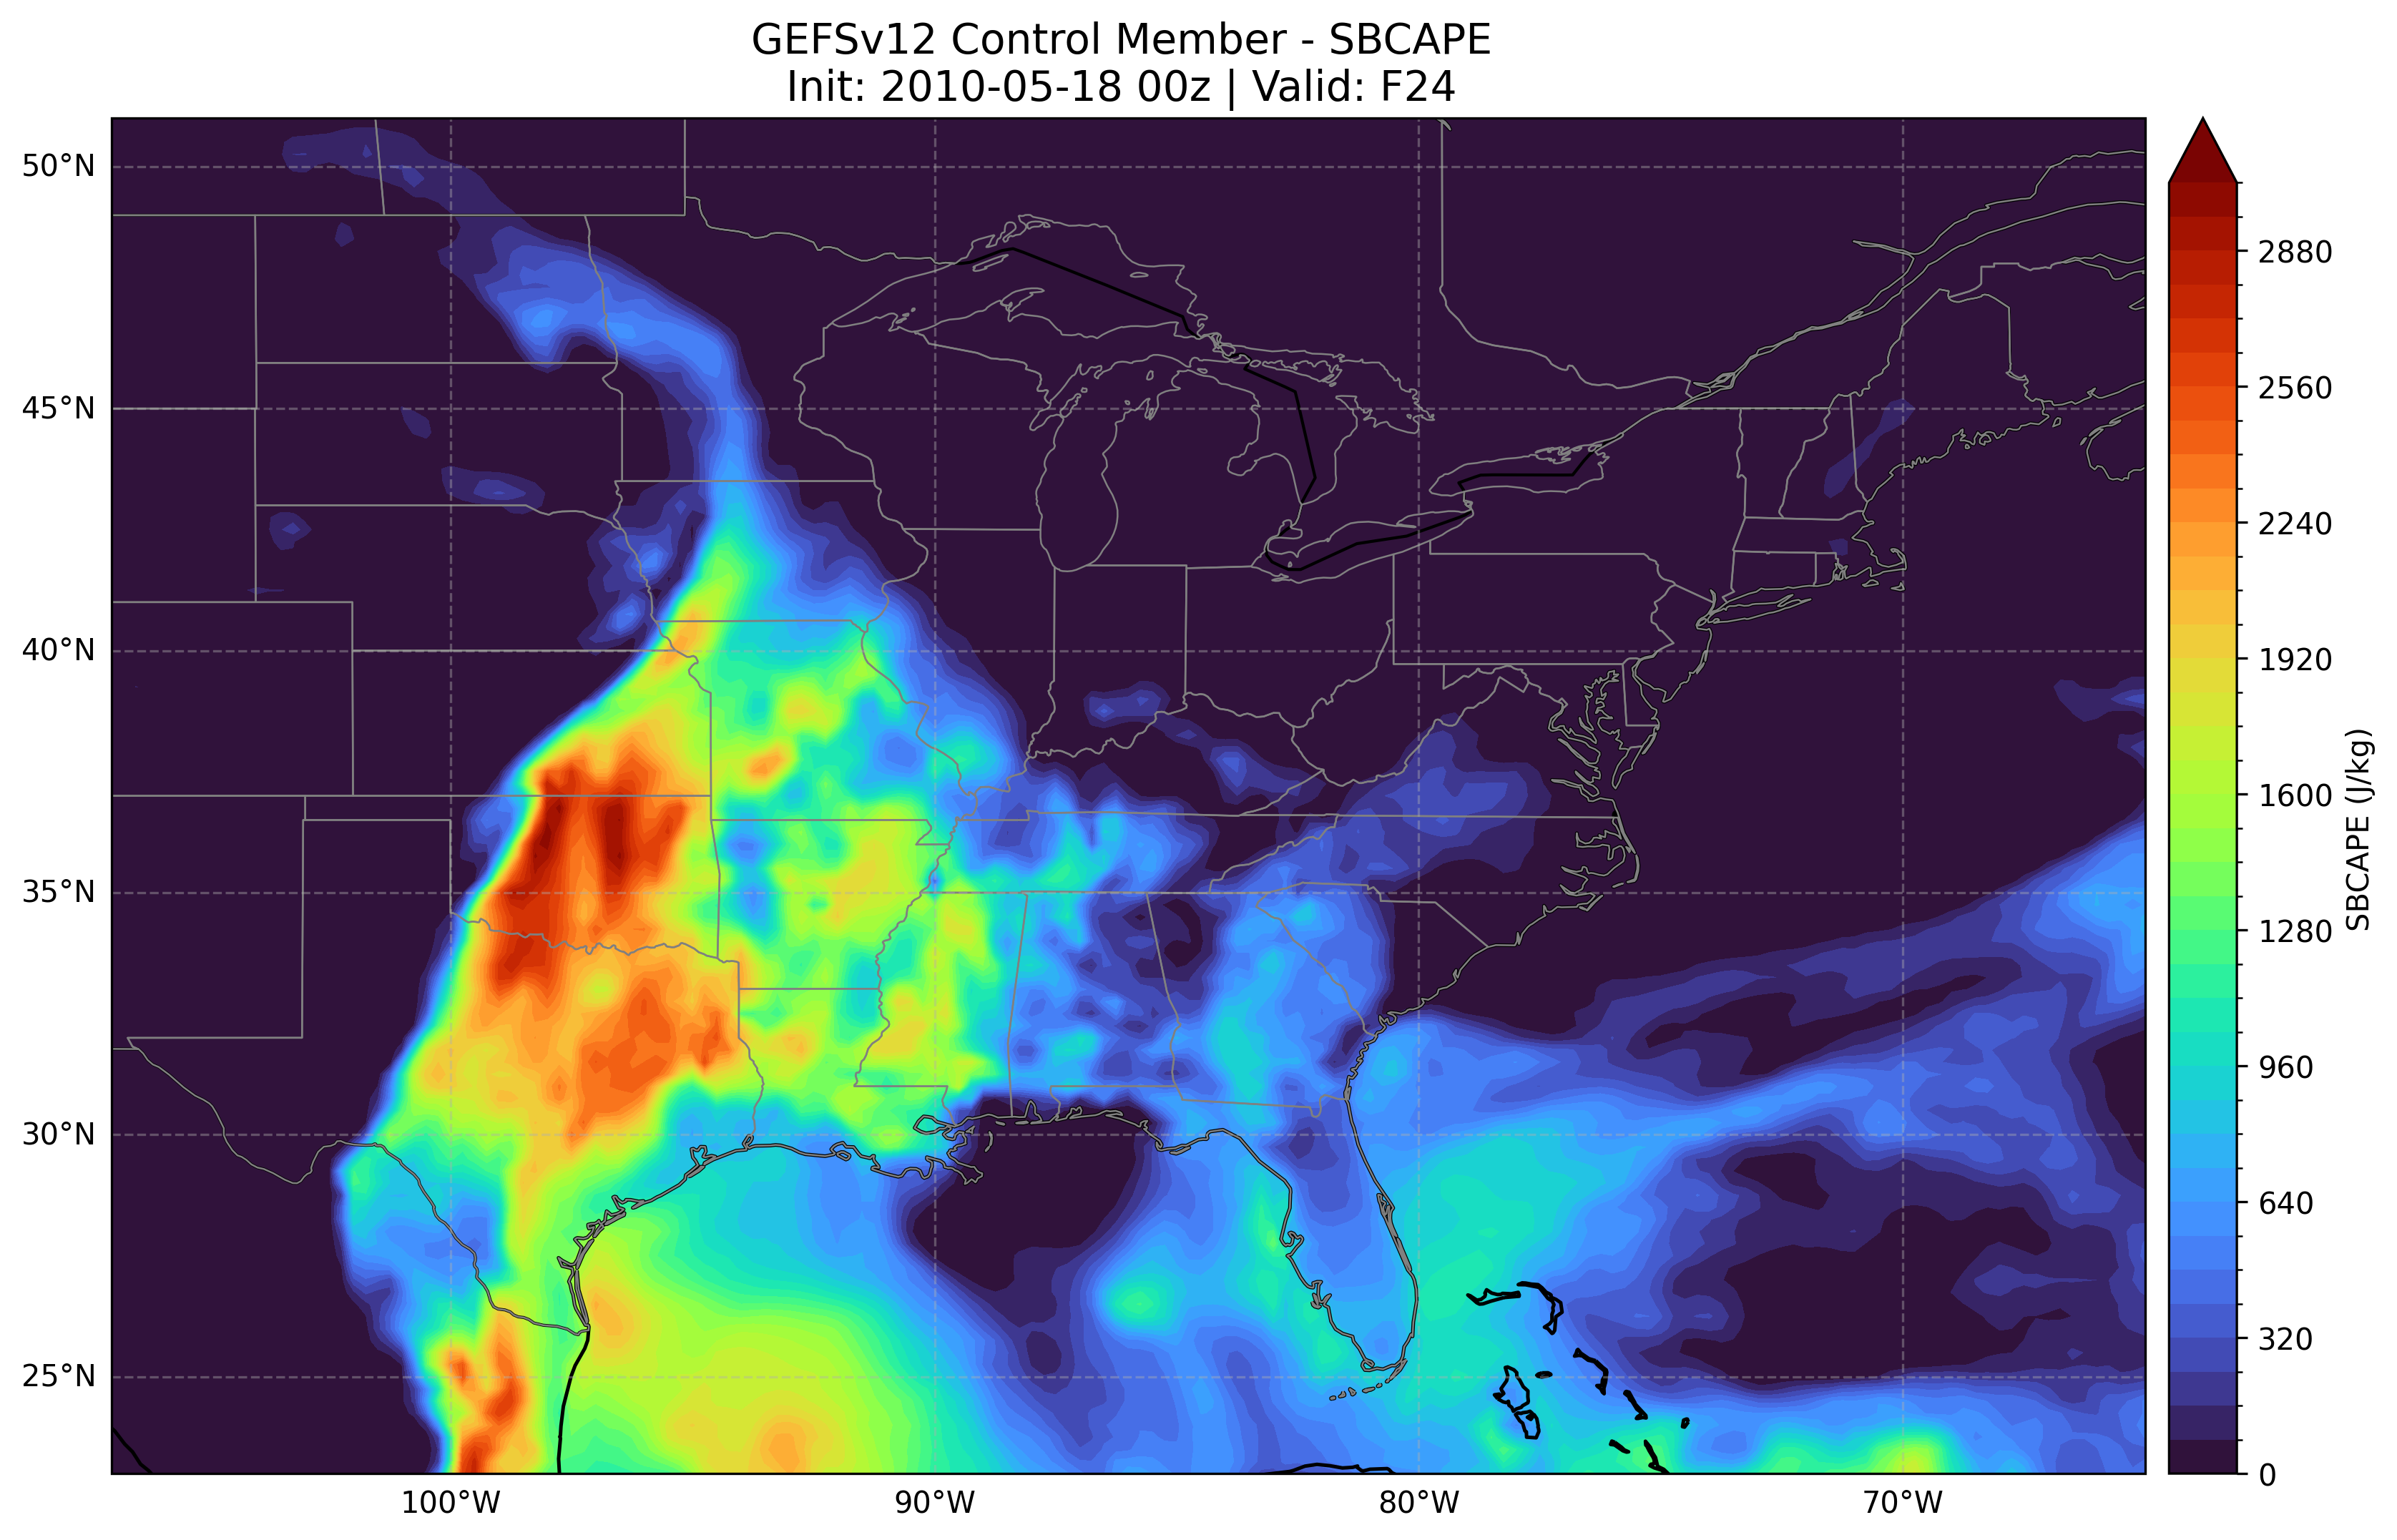

In [5]:
nc_file = "gefs_c00_2005051800_sbcape_subset.nc"

step_hours = 24

ds = xr.open_dataset(nc_file)

cape = ds['cape'].sel(step=pd.Timedelta(hours=step_hours))

fig = plt.figure(figsize=(12, 9), dpi=300)
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())

contour = cape.plot.contourf(ax=ax, cmap='turbo', levels=50, extend='max', transform=ccrs.PlateCarree(),
                          cbar_kwargs={'label': 'SBCAPE (J/kg)', 'shrink': 0.726, 'pad': 0.01})

ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=1.2)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=1.0)
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.6, edgecolor='gray')

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
gl.top_labels = False
gl.right_labels = False

plt.title(f"GEFSv12 Control Member - SBCAPE \nInit: 2010-05-18 00z | Valid: F{step_hours} ", fontsize=14)

plt.tight_layout()
plt.show()

In [6]:
ds

<xarray.Dataset> Size: 3MB
Dimensions:     (step: 40, latitude: 113, longitude: 169)
Coordinates:
  * step        (step) timedelta64[ns] 320B 0 days 06:00:00 ... 5 days 03:00:00
  * latitude    (latitude) float64 904B 51.0 50.75 50.5 ... 23.5 23.25 23.0
  * longitude   (longitude) float64 1kB -107.0 -106.8 -106.5 ... -65.25 -65.0
    number      int64 8B 0
    time        datetime64[ns] 8B 2005-05-18
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 320B ...
Data variables:
    cape        (step, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          2
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-11T09:45 GRIB to CDM+CF via cfgrib-0.9.1...